# 05 - Quantum error correction

QEC is conceptually hard the first time around because several things that work classically fail immediately: you cant copy the state (no-cloning), errors are continuous (any rotation is possible), and measuring to check for errors would collapse the logical state.

The resolution to all three:
- Entanglement substitutes for copying - the logical qubit is spread across multiple physical qubits in a way that any single qubit reveals no information about the logical state
- Syndrome measurement discretises errors - once you measure a stabilizer, the error is projected onto a Pauli operator, and correcting it is straightforward
- Syndromes are designed to commute with the logical operators but anticommute with errors - so you learn which error happened without learning the logical state

This notebook builds up from the simplest code (3-qubit bit flip) to the stabilizer formalism to a sketch of the surface code. Im mostly trying to understand how to actually implement syndrome circuits in qiskit and verify that the correction works.

In [1]:
print("working")

working


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.quantum_info import Statevector, DensityMatrix, state_fidelity

import warnings
warnings.filterwarnings('ignore')

sim = AerSimulator()

## 3-qubit bit flip code

Protects against a single X error on any of 3 qubits. The code space is
$$|0_L\rangle = |000\rangle, \quad |1_L\rangle = |111\rangle$$

The stabilizers are Z1Z2 and Z2Z3 - operators that have eigenvalue +1 on all code states. An X error on qubit k anticommutes with the stabilizers containing qubit k, flipping the syndrome from +1 to -1. The syndrome (pair of eigenvalues) uniquely identifies which qubit errored.

This code does nothing for Z errors - a Z on any qubit is a logical Z error. Thats why this alone isnt sufficient, but its a clean starting point.

In [3]:
# verify stabilizer properties by hand first
I = np.eye(2, dtype=complex)
X = np.array([[0,1],[1,0]], dtype=complex)
Z = np.array([[1,0],[0,-1]], dtype=complex)

Z1Z2 = np.kron(np.kron(Z,Z),I)
Z2Z3 = np.kron(np.kron(I,Z),Z)

ket000 = np.zeros(8); ket000[0] = 1
ket111 = np.zeros(8); ket111[7] = 1

for name, s in [('|000>',ket000),('|111>',ket111)]:
    ev1 = s @ (Z1Z2 @ s)
    ev2 = s @ (Z2Z3 @ s)
    print(f'Z1Z2 on {name}: {ev1:+.0f},  Z2Z3: {ev2:+.0f}')

print()
# after X error on qubit 0
X1II = np.kron(np.kron(X,I),I)
err_state = X1II @ ket000  # = |100>
print('after X_0 error:')
print(f'Z1Z2: {err_state @ (Z1Z2 @ err_state):+.0f},  Z2Z3: {err_state @ (Z2Z3 @ err_state):+.0f}')

Z1Z2 on |000>: +1+0j,  Z2Z3: +1+0j
Z1Z2 on |111>: +1+0j,  Z2Z3: +1+0j

after X_0 error:
Z1Z2: -1+0j,  Z2Z3: +1+0j


In [6]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

def bit_flip_circuit(initial='0', error_qubit=None):
    data = QuantumRegister(3, 'd')
    anc  = QuantumRegister(2, 'a')
    syn  = ClassicalRegister(2, 's')
    out  = ClassicalRegister(1, 'o')
    qc   = QuantumCircuit(data, anc, syn, out)

    if initial == '1': 
        qc.x(data[0])
    elif initial == '+': 
        qc.h(data[0])

    # encode
    qc.cx(data[0], data[1])
    qc.cx(data[0], data[2])
    qc.barrier()

    # Inyección de error
    if error_qubit is not None: 
        qc.x(data[error_qubit])
    qc.barrier()

    # syndrome - measure Z1Z2 and Z2Z3 via ancillas
    qc.cx(data[0], anc[0]); qc.cx(data[1], anc[0])
    qc.cx(data[1], anc[1]); qc.cx(data[2], anc[1])
    qc.measure(anc[0], syn[0])
    qc.measure(anc[1], syn[1])
    qc.barrier()

    # CORRECCIÓN: Sustitución de .c_if() por .if_test()
    # syn=01 (decimal 1): error on qubit 0
    with qc.if_test((syn, 1)):
        qc.x(data[0])
    
    # syn=11 (decimal 3): error on qubit 1
    with qc.if_test((syn, 3)):
        qc.x(data[1])
    
    # syn=10 (decimal 2): error on qubit 2
    with qc.if_test((syn, 2)):
        qc.x(data[2])
        
    qc.barrier()

    # decode and measure
    qc.cx(data[0], data[1]); qc.cx(data[0], data[2])
    qc.measure(data[0], out[0])
    
    return qc

In [7]:
# test all single-qubit errors
for err in [None, 0, 1, 2]:
    counts = sim.run(bit_flip_circuit('0', err), shots=1024).result().get_counts()
    p_correct = sum(v for k,v in counts.items() if k.split(' ')[0] == '0') / 1024
    print(f'error on qubit {err}: recovered |0> {100*p_correct:.1f}%')

error on qubit None: recovered |0> 100.0%
error on qubit 0: recovered |0> 100.0%
error on qubit 1: recovered |0> 100.0%
error on qubit 2: recovered |0> 100.0%


In [8]:
# same for logical |+> - should still get 50/50 after decode
for err in [None, 0, 1, 2]:
    counts = sim.run(bit_flip_circuit('+', err), shots=4096).result().get_counts()
    p0 = sum(v for k,v in counts.items() if k.split(' ')[0] == '0') / 4096
    print(f'error on qubit {err}: P(0)={p0:.3f}, P(1)={1-p0:.3f}')

error on qubit None: P(0)=0.501, P(1)=0.499
error on qubit 0: P(0)=0.515, P(1)=0.485
error on qubit 1: P(0)=0.498, P(1)=0.502
error on qubit 2: P(0)=0.508, P(1)=0.492


Good - the code corrects X errors on any single qubit, for both computational basis states and superpositions. The continuous error case is also handled: if a partial rotation epsilon*X occurs instead of a full bit flip, the syndrome measurement projects it onto either 'no error' or 'full X error' with respective probabilities. The code doesnt care that the original error was continuous.

## Shor code

Concatenate the bit-flip and phase-flip codes: protect against X errors within each block (bit-flip code), and protect against Z errors at the block level (phase-flip code). Result: 9 physical qubits per logical qubit, corrects any single-qubit error.

Encoding:
$$|0_L\rangle = \frac{(|000\rangle+|111\rangle)^{\otimes 3}}{2\sqrt{2}}, \quad |1_L\rangle = \frac{(|000\rangle-|111\rangle)^{\otimes 3}}{2\sqrt{2}}$$

In [9]:
def shor_encode():
    qc = QuantumCircuit(9)
    # phase-flip encoding at block level (qubits 0,3,6 are block representatives)
    qc.cx(0,3); qc.cx(0,6)
    qc.h(0); qc.h(3); qc.h(6)
    # bit-flip encoding within each block
    for start in [0, 3, 6]:
        qc.cx(start, start+1)
        qc.cx(start, start+2)
    return qc

# check encoding of |0>
qc_shor = QuantumCircuit(9)
qc_shor.compose(shor_encode(), inplace=True)
sv = Statevector(qc_shor)
nonzero = [(format(i,'09b'), np.round(sv.data[i].real, 4)) for i in range(512) if abs(sv.data[i]) > 1e-10]
print(f'{len(nonzero)} non-zero basis states (expect 8):')
for state, amp in nonzero:
    print(f'  |{state}> : {amp}')

8 non-zero basis states (expect 8):
  |000000000> : 0.3536
  |000000111> : 0.3536
  |000111000> : 0.3536
  |000111111> : 0.3536
  |111000000> : 0.3536
  |111000111> : 0.3536
  |111111000> : 0.3536
  |111111111> : 0.3536


The 9-qubit Shor code achieves something important: it corrects any single-qubit error, not just X or Z separately. A Y error is just X followed by Z, so if both are correctable independently, Y is too. Any other single-qubit error can be decomposed in the Pauli basis and the syndrome measurement projects it onto one of these cases.

## Stabilizer formalism

The Shor code is a [[9,1,3]] stabilizer code. The general framework: an n-qubit code on k logical qubits is defined by a stabilizer group S generated by n-k independent Pauli operators. The code space is the +1 eigenspace of all generators.

An error E is detectable iff it anticommutes with at least one generator. The syndrome measurement (measuring each generator) identifies E up to the correction group. The logical operators are Paulis that commute with all generators but are not in S - they act nontrivially on the logical qubit.

For the 3-qubit bit flip code:
- Generators: Z1Z2, Z2Z3
- Logical X_L = X1X2X3, logical Z_L = Z1 (or Z2 or Z3 - all equivalent in code space)
- Code distance = 3: minimum weight of a logical operator

In [10]:
# verify that X1X2X3 commutes with both stabilizers but is not in S
X1 = np.kron(np.kron(X,X),X)

# commutator [A,B] = 0 for commuting operators
def commutes(A, B):
    return np.allclose(A @ B, B @ A)

print('X_L commutes with Z1Z2:', commutes(X1, Z1Z2))
print('X_L commutes with Z2Z3:', commutes(X1, Z2Z3))

# X_L acting on |0_L> should give |1_L>
print('X_L |000>:', np.round(X1 @ ket000, 2))  # should be |111>

X_L commutes with Z1Z2: True
X_L commutes with Z2Z3: True
X_L |000>: [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j]


## Surface code (sketch)

The surface code is the leading candidate for fault tolerant quantum computing. The reasons:
- High threshold (~1% per gate) - within reach of current hardware
- Only nearest-neighbour interactions on a 2D grid
- For distance d, uses d^2 + (d-1)^2 physical qubits, logical error rate ~ (p/p_th)^{(d+1)/2}

The stabilizers are weight-4 Pauli operators on a 2D grid: XXXX on vertices (detect Z errors) and ZZZZ on plaquettes (detect X errors). The logical operators are strings of X or Z operators running across the lattice from one boundary to the other.

Full implementation including a MWPM decoder is non-trivial. Here I just want to see the syndrome structure for a d=3 code and verify that single errors produce the right syndrome pattern.

In [11]:
# rotated d=3 surface code: 9 data qubits on a 3x3 grid
# qubit labeling:
#  0 1 2
#  3 4 5
#  6 7 8

# 4 Z-type stabilizers (plaquettes) - detect X errors
Z_plaquettes = [[0,1,3,4], [1,2,4,5], [3,4,6,7], [4,5,7,8]]

# 4 X-type stabilizers (vertices) - detect Z errors  
X_vertices   = [[0,1,3,4], [1,2,4,5], [3,4,6,7], [4,5,7,8]]

def measure_z_stab(qc, data_qubits, ancilla, clbit):
    # ancilla in |+>, then CZ with each data qubit, then H back
    qc.h(ancilla)
    for dq in data_qubits: qc.cz(ancilla, dq)
    qc.h(ancilla)
    qc.measure(ancilla, clbit)

def measure_x_stab(qc, data_qubits, ancilla, clbit):
    qc.h(ancilla)
    for dq in data_qubits: qc.cx(ancilla, dq)
    qc.h(ancilla)
    qc.measure(ancilla, clbit)

data = QuantumRegister(9, 'd')
anc  = QuantumRegister(8, 'a')   # 4 Z ancillas + 4 X ancillas
synd = ClassicalRegister(8, 's')

qc_surf = QuantumCircuit(data, anc, synd)

# introduce X error on central qubit (index 4)
qc_surf.x(data[4])
qc_surf.barrier()

for i, plaq in enumerate(Z_plaquettes):
    measure_z_stab(qc_surf, [data[q] for q in plaq], anc[i], synd[i])
for i, vert in enumerate(X_vertices):
    measure_x_stab(qc_surf, [data[q] for q in vert], anc[i+4], synd[i+4])

counts = sim.run(qc_surf, shots=256).result().get_counts()
most_common = max(counts, key=counts.get)
print(f'syndrome: {most_common}')
print(f'Z syndromes (bits 0-3): {most_common[-4:]}')
print(f'X syndromes (bits 4-7): {most_common[:4]}')
print('qubit 4 is in all 4 Z-plaquettes -> expect Z syndrome = 1111')

syndrome: 00001111
Z syndromes (bits 0-3): 1111
X syndromes (bits 4-7): 0000
qubit 4 is in all 4 Z-plaquettes -> expect Z syndrome = 1111


## Logical error rate vs code distance

The key result of fault-tolerant QEC: below the error threshold p_th, increasing code distance exponentially suppresses the logical error rate. For the bit-flip repetition code its easy to derive analytically - logical failure requires at least ceil((d+1)/2) physical errors, so P_L ~ C(d, ceil) * p^{ceil}.

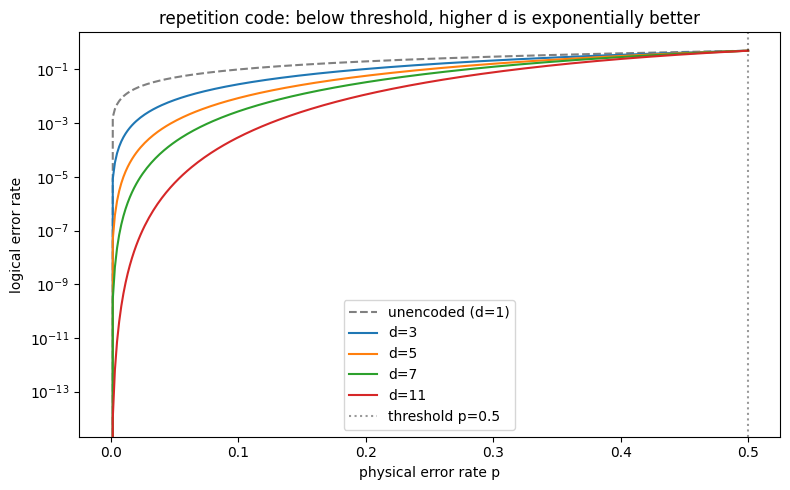

In [12]:
# analytical logical error rate for repetition code
# P_L = sum_{k=t+1}^{d} C(d,k) p^k (1-p)^{d-k}  where t = floor(d/2)

from scipy.special import comb

def p_logical(p, d):
    t = d // 2
    return sum(comb(d,k,exact=True) * p**k * (1-p)**(d-k) for k in range(t+1, d+1))

p_range = np.linspace(0, 0.5, 300)

plt.figure(figsize=(8,5))
plt.semilogy(p_range, p_range, '--', color='gray', label='unencoded (d=1)')
for d in [3, 5, 7, 11]:
    plt.semilogy(p_range, [p_logical(p, d) for p in p_range], label=f'd={d}')
plt.axvline(0.5, color='black', linestyle=':', alpha=0.4, label='threshold p=0.5')
plt.xlabel('physical error rate p')
plt.ylabel('logical error rate')
plt.title('repetition code: below threshold, higher d is exponentially better')
plt.legend(); plt.tight_layout(); plt.show()

# the surface code threshold is around 1% not 50%, but the qualitative picture is the same

The crossing point at p=0.5 is the threshold for this code. The surface code has p_th ~ 1%, which is more realistic for hardware.

Things I havent done here that would be the natural next step:
- MWPM decoding for the surface code (needs pymatching)
- Multiple rounds of syndrome measurement - ancilla errors propagate and have to be handled
- Transversal logical gates - the whole point of having a code is being able to compute on it
- Magic state distillation for non-Clifford gates